<a href="https://colab.research.google.com/github/shihab-iiuc/ML-Other-Topics-Learning/blob/main/C221094_Class_8_%26_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount The Drive

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#import Library

In [58]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


#Load and Prepare MNIST Dataset


```
Dataset Link: https://www.kaggle.com/datasets/hojjatk/mnist-dataset
```



In [59]:
path='/content/drive/MyDrive/Mnist'

def load_images(path):
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28, 28)

def load_labels(path):
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

train_images = load_images("/content/drive/MyDrive/Mnist/train-images.idx3-ubyte")
train_labels = load_labels("/content/drive/MyDrive/Mnist/train-labels.idx1-ubyte")

test_images = load_images("/content/drive/MyDrive/Mnist/t10k-images.idx3-ubyte")
test_labels = load_labels("/content/drive/MyDrive/Mnist/t10k-labels.idx1-ubyte")

print("Loaded data:", train_images.shape, train_labels.shape)
# Normalize to [0,1]
train_images = torch.tensor(train_images, dtype=torch.float32) / 255.0
test_images  = torch.tensor(test_images,  dtype=torch.float32) / 255.0

train_labels = torch.tensor(train_labels, dtype=torch.long)
test_labels  = torch.tensor(test_labels,  dtype=torch.long)

# Add channel dimension → (N,1,28,28)
train_images = train_images.unsqueeze(1)
test_images  = test_images.unsqueeze(1)

print(train_images.shape)

trainset = TensorDataset(train_images, train_labels)
testset  = TensorDataset(test_images,  test_labels)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = DataLoader(testset, batch_size=64, shuffle=False)

classes = tuple(str(i) for i in range(10))

print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")
print(f"Number of classes: {len(classes)}")

Loaded data: (60000, 28, 28) (60000,)
torch.Size([60000, 1, 28, 28])
Training samples: 60000
Test samples: 10000
Number of classes: 10


#3.Visulize Sample Images

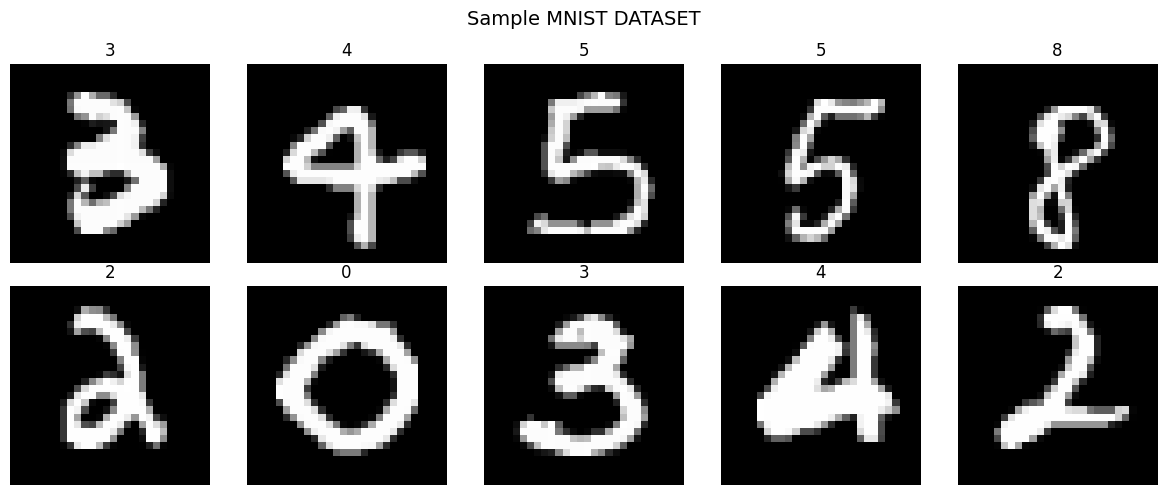

In [61]:
# Get a batch of training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show 10 sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images[i] / 2 + 0.5  # unnormalize
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(img,cmap='gray')
    ax.set_title(classes[labels[i]])
    ax.axis('off')
plt.suptitle('Sample MNIST DATASET', fontsize=14)
plt.tight_layout()
plt.show()

#Define CNN Model

In [62]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 28 → 14
        x = self.pool(self.relu(self.conv2(x)))  # 14 → 7
        x = self.pool(self.relu(self.conv3(x)))  # 7 → 3

        x = x.view(x.size(0), -1)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x
model = SimpleCNN().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Total parameters: 390,410


#Define Loss Function and optimizer

In [63]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(f'Loss: {criterion}')
print(f'{optimizer}')


Loss: CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


#Train the Model

In [64]:
num_epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(trainloader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

print('\nTraining complete!')

Epoch [1/10] - Loss: 0.2049, Accuracy: 93.37%
Epoch [2/10] - Loss: 0.0550, Accuracy: 98.33%
Epoch [3/10] - Loss: 0.0394, Accuracy: 98.83%
Epoch [4/10] - Loss: 0.0311, Accuracy: 99.05%
Epoch [5/10] - Loss: 0.0242, Accuracy: 99.26%
Epoch [6/10] - Loss: 0.0196, Accuracy: 99.39%
Epoch [7/10] - Loss: 0.0176, Accuracy: 99.45%
Epoch [8/10] - Loss: 0.0153, Accuracy: 99.50%
Epoch [9/10] - Loss: 0.0134, Accuracy: 99.58%
Epoch [10/10] - Loss: 0.0109, Accuracy: 99.63%

Training complete!


Save the model

In [65]:
torch.save(model.state_dict(), '/content/drive/MyDrive/Mnist/mnist_cnn_model.pth')
print('Model saved successfully!')

Model saved successfully!


#Plot training loss and Accuracy

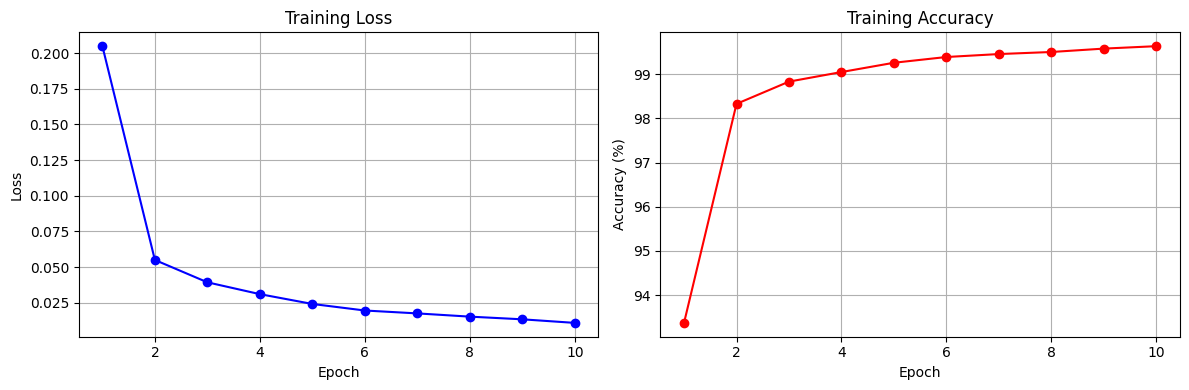

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, num_epochs+1), train_losses, 'b-o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(range(1, num_epochs+1), train_accuracies, 'r-o')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True)

plt.tight_layout()
plt.show()

#Evaluate on Test Set

In [67]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 99.26%


#Per-Class Accuracy

In [68]:
# Per-class accuracy
class_correct = [0] * 10
class_total = [0] * 10

for pred, label in zip(all_preds, all_labels):
    class_total[label] += 1
    if pred == label:
        class_correct[label] += 1

print('Per-class accuracy:')
print('-' * 30)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f'{classes[i]:>12s}: {acc:.1f}%')

Per-class accuracy:
------------------------------
           0: 99.7%
           1: 99.6%
           2: 99.6%
           3: 99.3%
           4: 99.7%
           5: 99.0%
           6: 98.7%
           7: 99.0%
           8: 99.4%
           9: 98.5%


#Classification Report

In [69]:
print(classification_report(all_labels, all_preds, target_names=classes))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



#Confusion Matrix

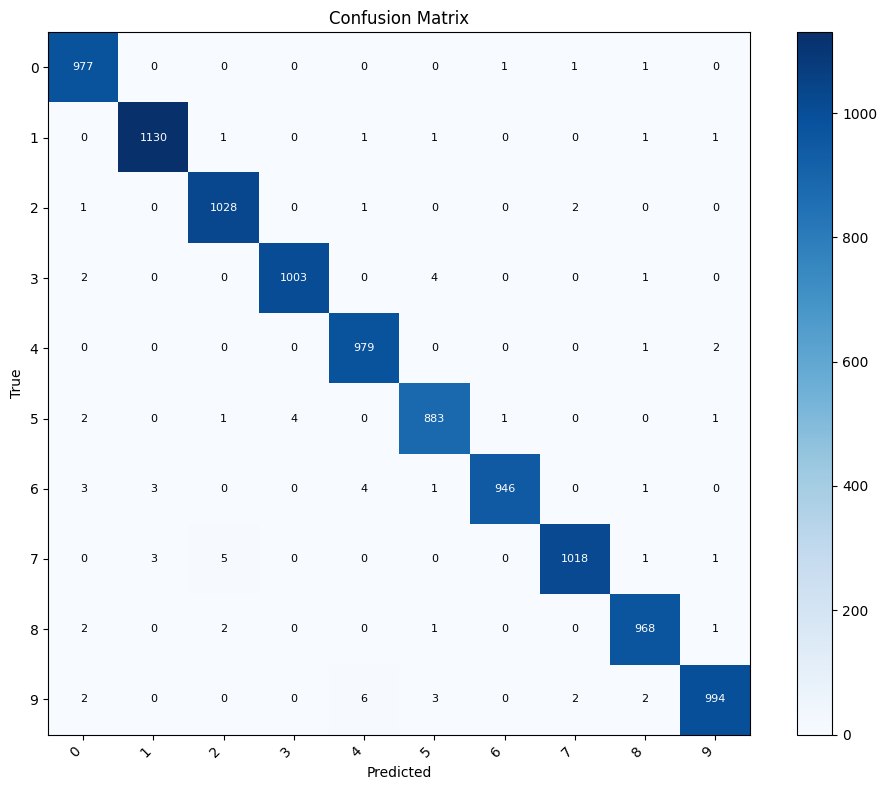

In [70]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('Confusion Matrix')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticklabels(classes)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

# Add text annotations
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()

#Visualize Predictions

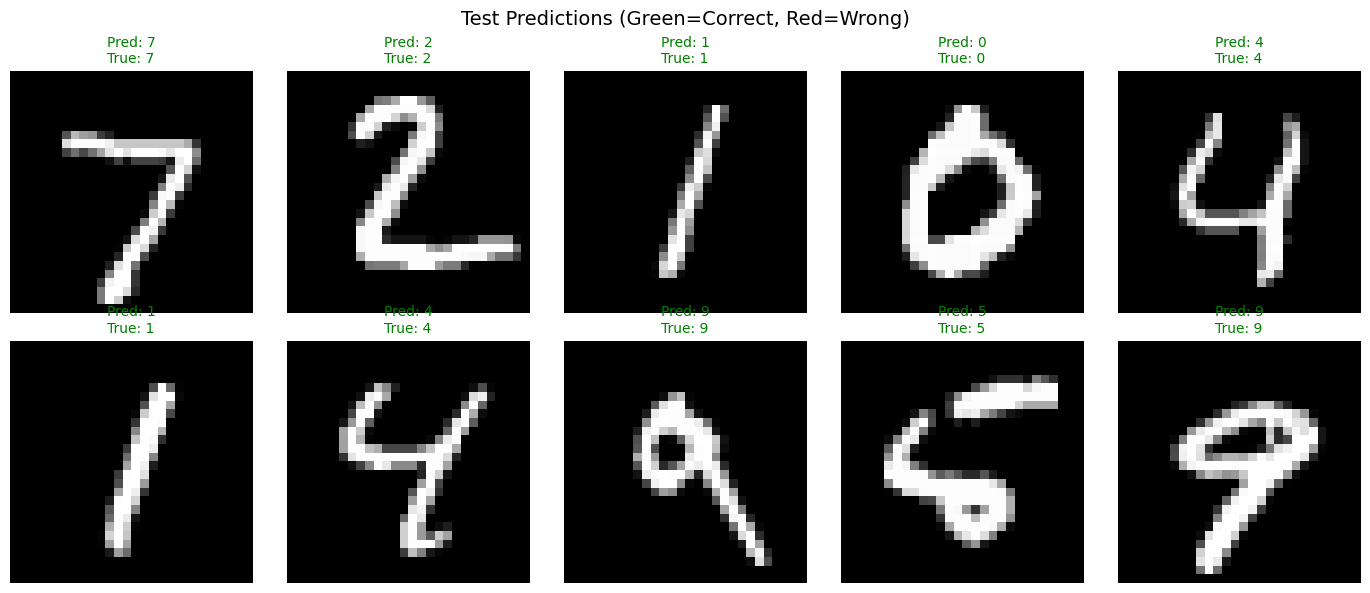

In [72]:
# Show some test predictions
dataiter = iter(testloader)
images, labels = next(dataiter)

model.eval()
with torch.no_grad():
    outputs = model(images.to(device))
    _, preds = torch.max(outputs, 1)
    preds = preds.cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = images[i] / 2 + 0.5  # unnormalize
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(img,cmap="gray")
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f'Pred: {classes[preds[i]]}\nTrue: {classes[labels[i]]}', color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('Test Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()